## Predictive Maintenance & Failure Detection System

### Life cycle of Machine learning Project
   * Understanding the Problem Statement
   * Data Collection
   * Data Checks to perform
   * Exploratory data analysis
   * Data Pre-Processing
   * Model Training
   * Choose best model

## 1) Problem statement
* Unexpected machine failures can lead to production downtime, increased maintenance costs, and reduced operational efficiency. The objective of this project is to analyze machine operating data, identify patterns that indicate potential failures, and develop a predictive system that enables timely maintenance before breakdowns occur.

## 2) Data Collection
* Dataset Source - https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset
* The data consists of 14 column and 10000 rows.

### 2.1 Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### Import the CSV Data as Pandas DataFrame

In [2]:
df = pd.read_csv('../notebooks/data/ai4i2020.csv')

#### Shows top 5 rows

In [3]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


#### Shape of the dataset

In [4]:
df.shape

(10000, 14)

### 2.2 Dataset information
* UDI : Unique identifier for each machine record.
* Product ID : Unique product identifier consisting of a product type and serial number.
* Type : Product quality category → (L: Low, M: Medium, H: High).
* Air Temperature [K] : Ambient air temperature measured in Kelvin.
* Process Temperature [K] : Temperature of the manufacturing process measured in Kelvin.
* Rotational Speed [rpm] : Rotational speed of the machine in revolutions per minute.
* Torque [Nm] : Torque applied by the machine measured in Newton-meters.
* Tool Wear [min] : Tool wear duration measured in minutes.
#### Target Variables
* Machine Failure : Indicates whether a machine failure occurred → (0: No Failure, 1: Failure).
* TWF (Tool Wear Failure) : Failure due to excessive tool wear → (0/1).
* HDF (Heat Dissipation Failure) : Failure caused by inadequate heat dissipation → (0/1).
* PWF (Power Failure) : Failure caused by power-related issues → (0/1).
* OSF (Overstrain Failure) : Failure due to excessive strain on the machine → (0/1).
* RNF (Random Failure) : Randomly occurring failure → (0/1).

## 3. Data Checks to perform
* Check Missing values
* Check Duplicates
* Check data type
* Check the number of unique values of each column
* Check statistics of data set
* Check various categories present in the different categorical column

### 3.1 Check Missing values

In [5]:
df.isna().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

##### There is no null or missing value 

#### 3.2 Checking duplicates

In [6]:
df.duplicated().sum()

np.int64(0)

##### There are no duplicates values in the data set

#### 3.3 Checking data types

In [7]:
#checking null and datatype
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

#### 3.4 Checking the number of unique values of each column

In [8]:
df.nunique()

UDI                        10000
Product ID                 10000
Type                           3
Air temperature [K]           93
Process temperature [K]       82
Rotational speed [rpm]       941
Torque [Nm]                  577
Tool wear [min]              246
Machine failure                2
TWF                            2
HDF                            2
PWF                            2
OSF                            2
RNF                            2
dtype: int64

#### 3.5 Check statistics of data set

In [9]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


##### Insights
* Here overall machine failure have mean of 0.339 but other have too low tendency.
* Air and Process Temperatures are within a consistent operating range.
* Rotational Speed and Torque show noticeable variation across machines.
* Tool Wear has a wide range, indicating machines operate under different wear conditions.
* Some features may contain outliers due to large differences between quartiles and maximum values.

#### 3.7 Exploring Data

In [10]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [11]:
print(f"Categories in 'Type' variable:  {df['Type'].unique().to_numpy()}")

Categories in 'Type' variable:  ['M' 'L' 'H']


In [12]:
#define categorical and numerical columns
numeric_features = df.select_dtypes(include='number').columns.tolist()
categorical_features = df.select_dtypes(exclude='number').columns.tolist()

print(f"We have {(len(numeric_features))} Numeric features: {numeric_features}")
print(f"We have {(len(categorical_features))} categorical features: {categorical_features}")

We have 12 Numeric features: ['UDI', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
We have 2 categorical features: ['Product ID', 'Type']


In [13]:
target_features = df[['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']]

In [14]:
for feature in target_features:
    print(f"value count of fail and pass {feature}: {df[feature].value_counts()}")

value count of fail and pass Machine failure: Machine failure
0    9661
1     339
Name: count, dtype: int64
value count of fail and pass TWF: TWF
0    9954
1      46
Name: count, dtype: int64
value count of fail and pass HDF: HDF
0    9885
1     115
Name: count, dtype: int64
value count of fail and pass PWF: PWF
0    9905
1      95
Name: count, dtype: int64
value count of fail and pass OSF: OSF
0    9902
1      98
Name: count, dtype: int64
value count of fail and pass RNF: RNF
0    9981
1      19
Name: count, dtype: int64


##### So insight about failure of machine
* there have less number of TWF and RNF failures occured
* other have a failure rate but not much significant

### 4. Exploring Data ( Visualization )

#### 4.1 Visulizing Machine failure and its type.
* using count plot

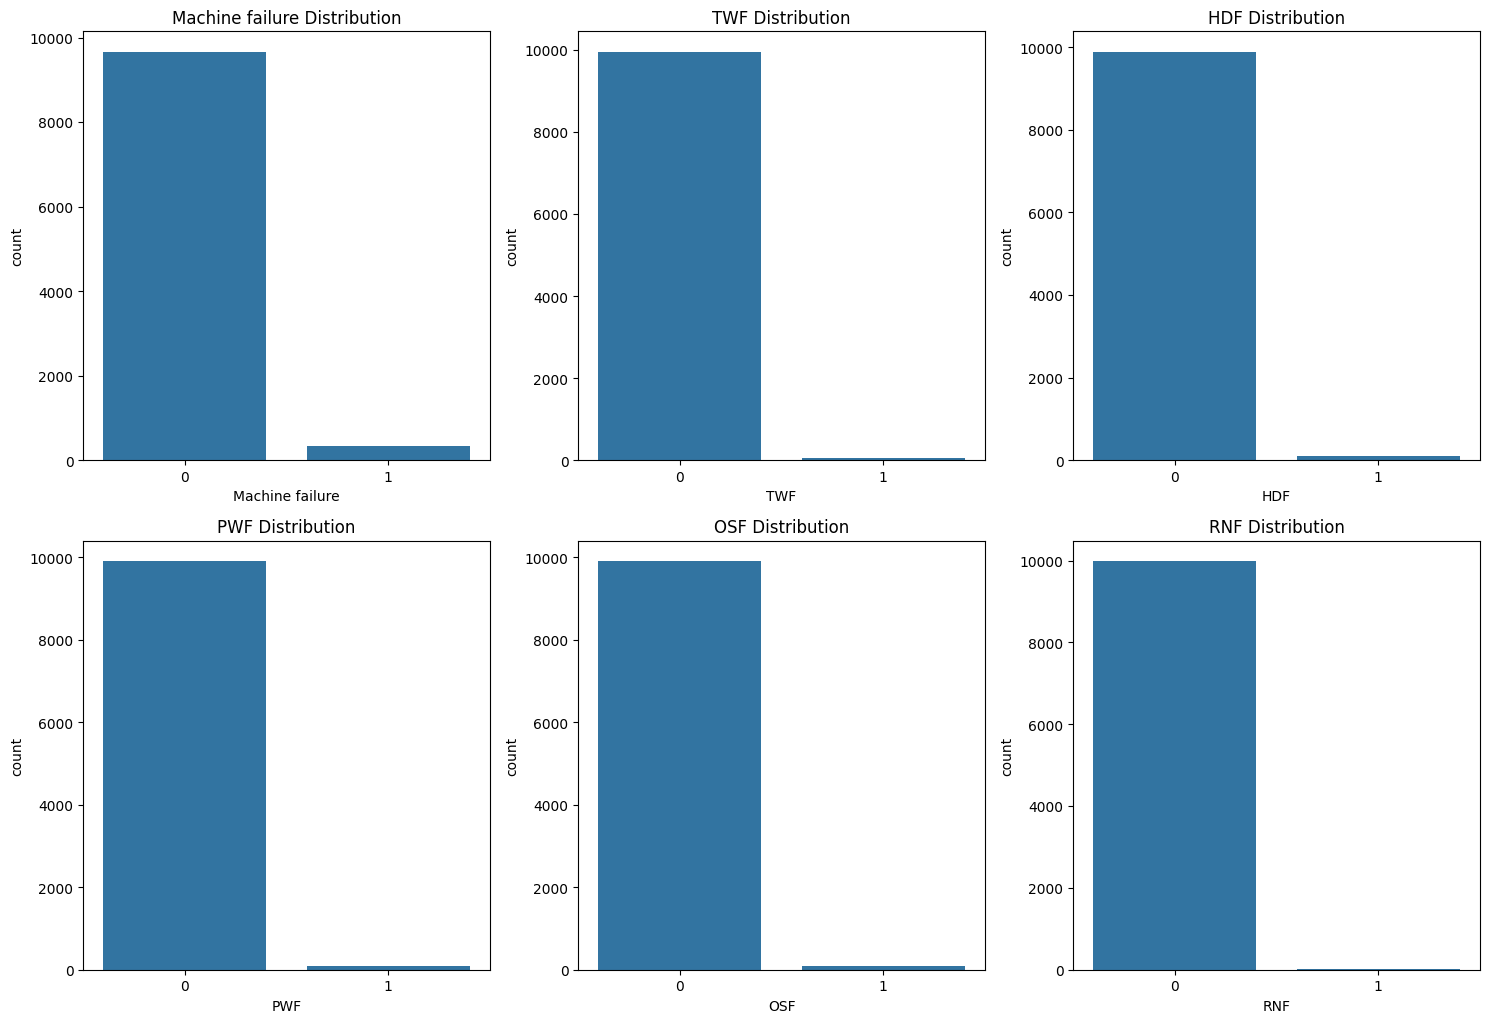

In [15]:
plt.figure(figsize=(15,15))

for i, feature in enumerate(target_features):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data=df, x=feature)
    plt.title(f"{feature} Distribution")

plt.tight_layout()
plt.show()

#### 4.2 Visulizing Type of machine failures

In [16]:
df['Type'].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

<Axes: xlabel='Type', ylabel='count'>

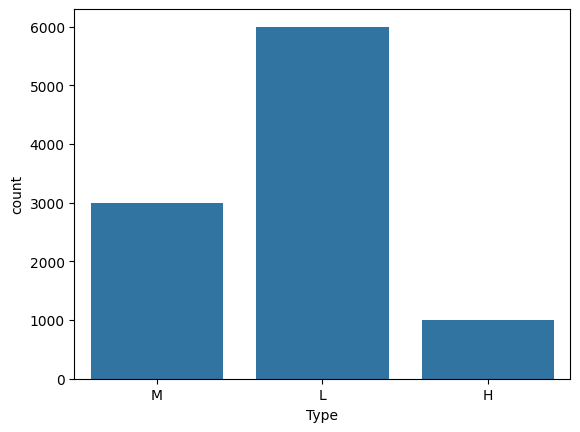

In [17]:
sns.countplot(x=df['Type'], data=df)

### Univariate Analysis

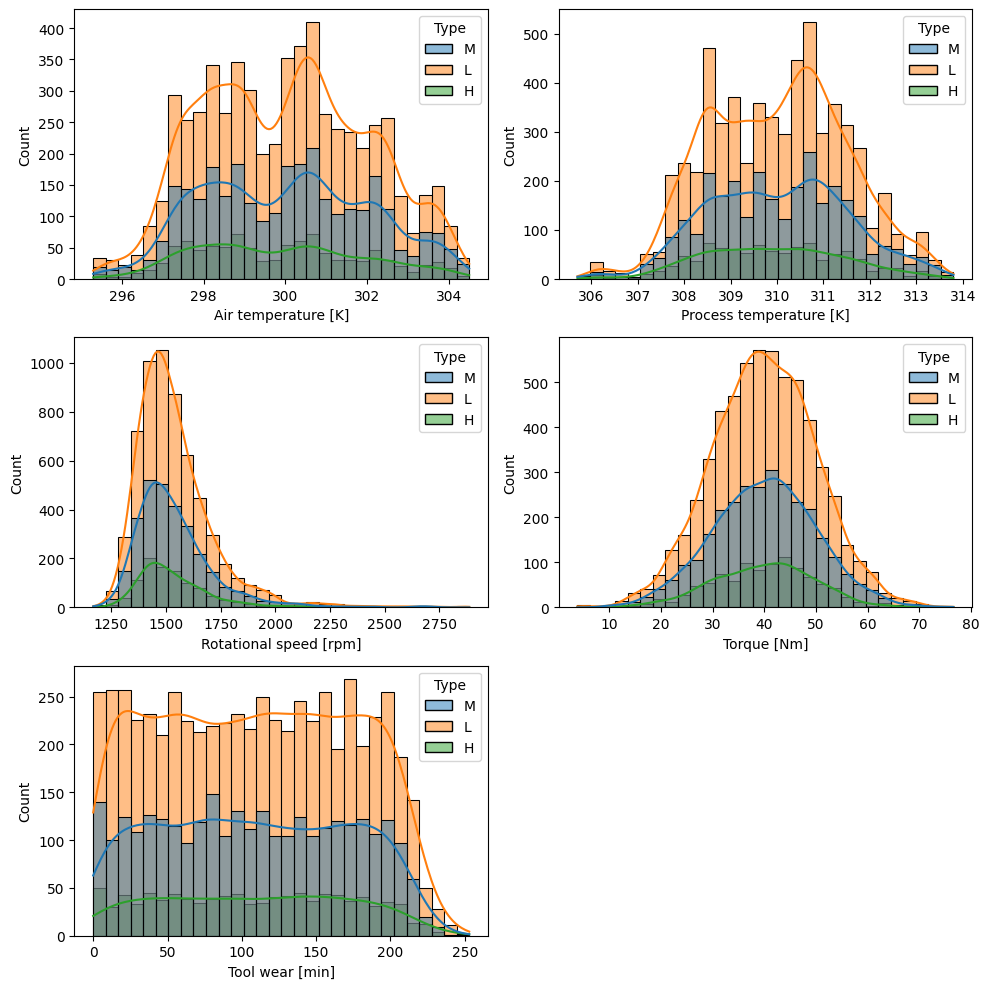

In [18]:
continuous_features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

plt.figure(figsize=(10,10))
for i, feature in enumerate(continuous_features):
    plt.subplot(3, 2, i + 1)
    sns.histplot(x=feature, kde=True,bins=30, color='B', data=df, hue='Type')
plt.tight_layout()
plt.show()

#### On the basis of histplot with type of machine we got insights
1) Air Temperature (K)
    * Air temperature is normally distributed.
    * Distribution of L, M and H product types overlap significantly.
    * No major difference among product categories
2) Process Temperature (K):
    * Process temperature also follows near-normal distribution.
    * Strong overlap exists among product categories.
3) Rotational Speed:
    * The distribution is positively skewed (right-skewed).
    * mostly machine operate on 1200-1700 rpm.
    * Some outliers exist on high rpm.
4) Torque (Nm):
    * Torque has approximetly normal distribution centered around 40Nm.
    * Product types has similar torque pattern.
    * some has high torque.
5) Tool Wear (min):
    * Tool wear uniformly distributed across operating range.
    * Machines are observed at various wear levels, providing a balanced representation of wear conditions.
    * Higher tool wear values may be associated with increased failure risk and should be investigated further.
##### Overall Observation
* Product types (L, M, H) show substantial overlap across all numerical features.
* Rotational speed exhibits noticeable skewness and potential outliers.
* Air temperature and process temperature appear well-behaved and approximately normally distributed.
* Further analysis against the target variable (Machine Failure) is required to identify features that influence failures. 

## Bivariate Analysis with Target

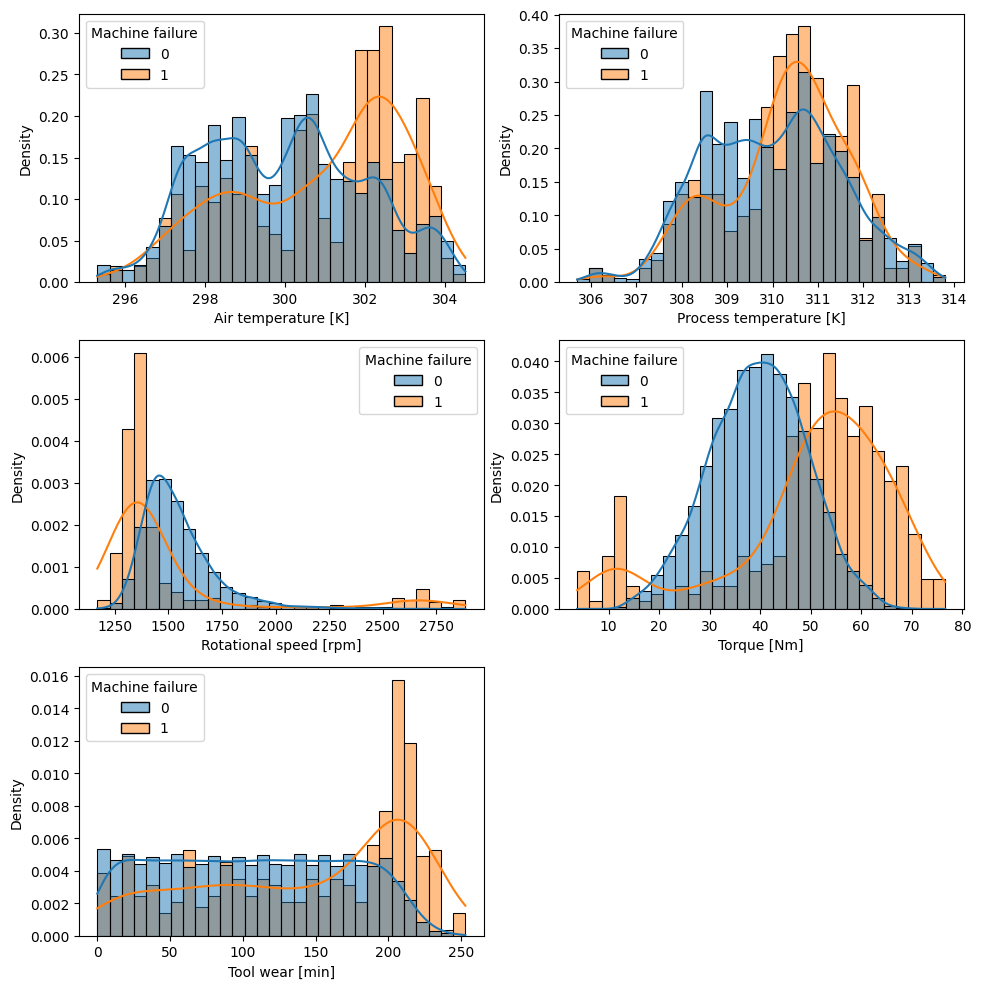

In [24]:
plt.figure(figsize=(10,10))
for i, feature in enumerate(continuous_features):
    plt.subplot(3, 2, i + 1)
    sns.histplot(x=feature, hue='Machine failure', data=df, kde=True, color='blue', bins=30, stat='density',common_norm=False)
plt.tight_layout()
plt.show()

#### Insights
* These distribution indicates that machine failure is highly associated with high torque and increased tool wear, elevated process temperature and lower rotational speed. Among all features Torque and Tool wear exhibits strong seperation between failure and non-failure of machine, might be most influential predictors of machine failure.

## Outlier Analysis

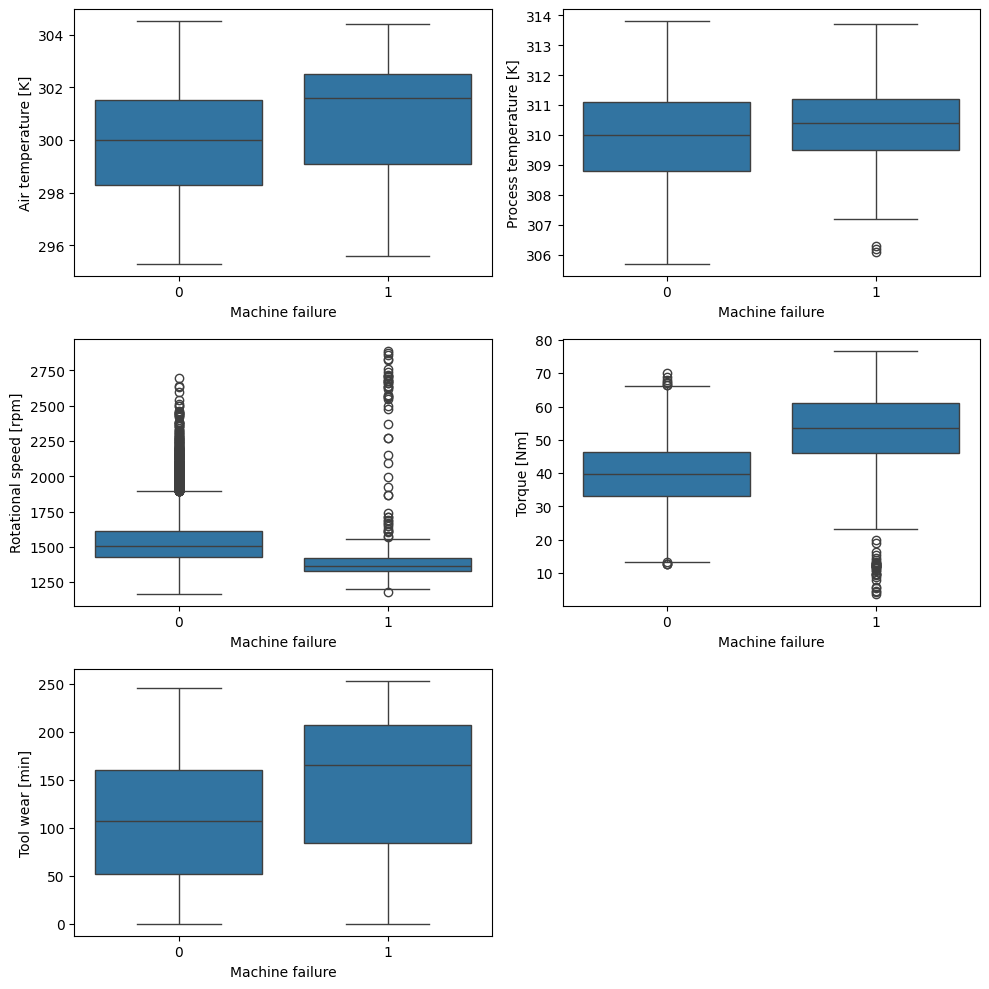

In [28]:
plt.figure(figsize=(10,10))

for i, feature in enumerate(continuous_features):
    plt.subplot(3, 2, i + 1) 
    sns.boxplot(x='Machine failure', y=feature, data=df)
    
plt.tight_layout()
plt.show()

#### Insights:
* The boxplots reveal noticeable differences between failed and non-failed machines. Failed machines tend to operate with higher torque, greater tool wear, and lower rotational speeds. Air temperature and process temperature are also slightly higher for failed machines, although the separation is less pronounced. Among all features, torque and tool wear exhibit the strongest association with machine failures and are expected to be important predictors in the machine learning model.

# Conclusion

 The exploratory data analysis revealed that dataset have both operational and failure0related data with no significant data quilty issue. The machine failure is highly imbalanced with small portion of failure oberservation.

Analysis of numerical variable shows that torque, tool wear and rotational speed has the strongest relationship with machine failure. Failed machine generally operate at higher torque, low rotational speed and greater tool wear. Air temperature and process temperature also exhibits some difference between machine failure and non-failure but thier impact appears less significant.

Furthermore, the product type (L, M, H) show substential overlap across most numerical features, indicating that thier alone apperance may not be enough.

Key Findings
* Dataset is highly imbalanced with very few failure cases.
* Torque and Tool Wear are the most influential features.
* Lower Rotational Speed is associated with higher failure occurrence.
* Air Temperature and Process Temperature show moderate influence.
* Product Type (L, M, H) has limited discriminatory power.
* Outliers are present, particularly in Rotational Speed and Torque, and should be handled carefully during model development.
* Feature engineering and imbalance-handling techniques may improve predictive performance.